# Data Exploration — FEVER Dev Set
Statistics on the full FEVER `dev.jsonl`: label distribution, claim length, evidence count,
evidence passage length, evidence count by label, and prompt token budget estimate.
No LLM calls — embedding-free.

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

K = cfg["retrieval"]["k"]
print("Config loaded. fever_dev:", cfg["dataset"]["fever_dev"], f"| k={K}")

Config loaded. fever_dev: data/fever/dev.jsonl | k=5


In [8]:
from src.data.fever_loader import load_fever

examples = load_fever("../" + cfg["dataset"]["fever_dev"])
df = pd.DataFrame(examples)
df["claim_len"] = df["claim"].str.split().str.len()
df["evidence_count"] = df["evidence"].str.len()
# evidence passage length: mean word count across all passages for each claim
df["evidence_mean_words"] = df["evidence"].apply(
    lambda evs: sum(len(e.split()) for e in evs) / len(evs) if evs else 0
)

print(f"Total examples : {len(df):,}")
print(f"Label counts   :\n{df['label'].value_counts().to_string()}")

Total examples : 15,935
Label counts   :
label
NOT ENOUGH INFO    6410
REFUTES            4887
SUPPORTS           4638


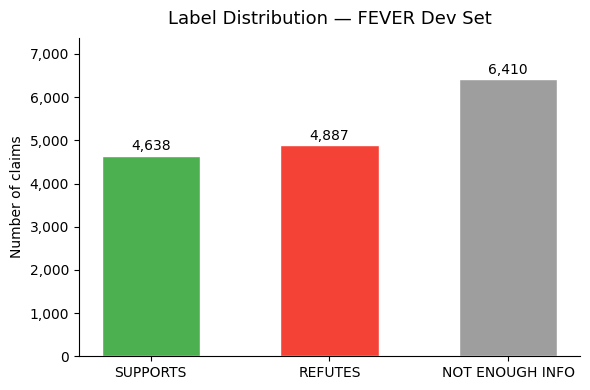

Saved → figures/01_label_distribution.png


In [9]:
# --- Label distribution ---
LABEL_ORDER = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
COLORS = ["#4CAF50", "#F44336", "#9E9E9E"]

counts = df["label"].value_counts().reindex(LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(LABEL_ORDER, counts.values, color=COLORS, edgecolor="white", width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Label Distribution — FEVER Dev Set", fontsize=13, pad=10)
ax.set_ylabel("Number of claims")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_label_distribution.png")

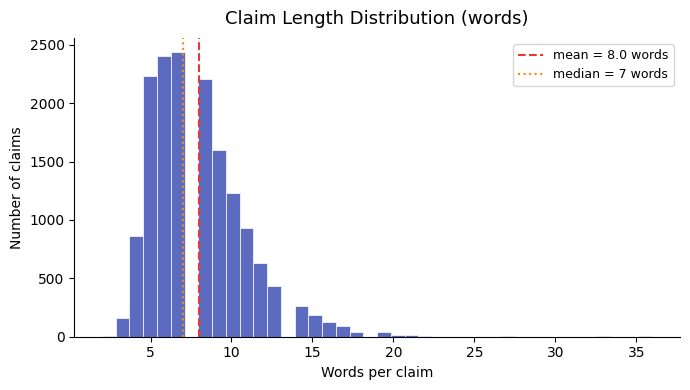

Saved → figures/01_claim_length.png

Claim length stats (words):
count    15935.000000
mean         7.971886
std          2.958962
min          2.000000
25%          6.000000
50%          7.000000
75%         10.000000
max         36.000000


In [10]:
# --- Claim length distribution ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["claim_len"], bins=40, color="#5C6BC0", edgecolor="white", linewidth=0.5)
ax.axvline(df["claim_len"].mean(), color="#E53935", linestyle="--", linewidth=1.5,
           label=f"mean = {df['claim_len'].mean():.1f} words")
ax.axvline(df["claim_len"].median(), color="#FB8C00", linestyle=":", linewidth=1.5,
           label=f"median = {df['claim_len'].median():.0f} words")

ax.set_title("Claim Length Distribution (words)", fontsize=13, pad=10)
ax.set_xlabel("Words per claim")
ax.set_ylabel("Number of claims")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_claim_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_claim_length.png")

print(f"\nClaim length stats (words):")
print(df["claim_len"].describe().to_string())

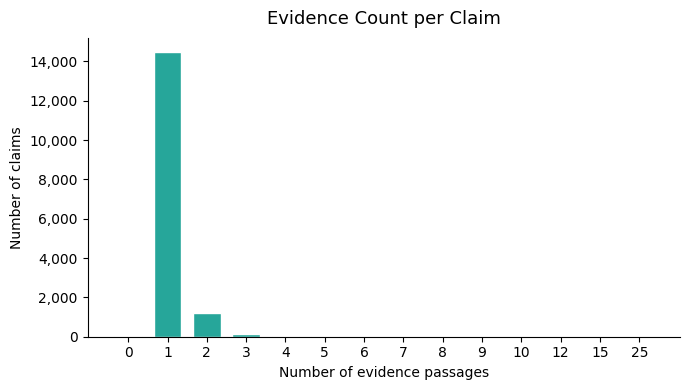

Saved → figures/01_evidence_count.png

Evidence count stats:
count    15935.000000
mean         1.111767
std          0.513160
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         25.000000

Claims with 0 evidence: 62 (0.4%)


In [11]:
# --- Evidence count distribution ---
ev_counts = df["evidence_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ev_counts.index.astype(str), ev_counts.values,
       color="#26A69A", edgecolor="white", width=0.7)

ax.set_title("Evidence Count per Claim", fontsize=13, pad=10)
ax.set_xlabel("Number of evidence passages")
ax.set_ylabel("Number of claims")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_evidence_count.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_evidence_count.png")

print(f"\nEvidence count stats:")
print(df["evidence_count"].describe().to_string())
zero_ev = (df["evidence_count"] == 0).sum()
print(f"\nClaims with 0 evidence: {zero_ev:,} ({100 * zero_ev / len(df):.1f}%)")

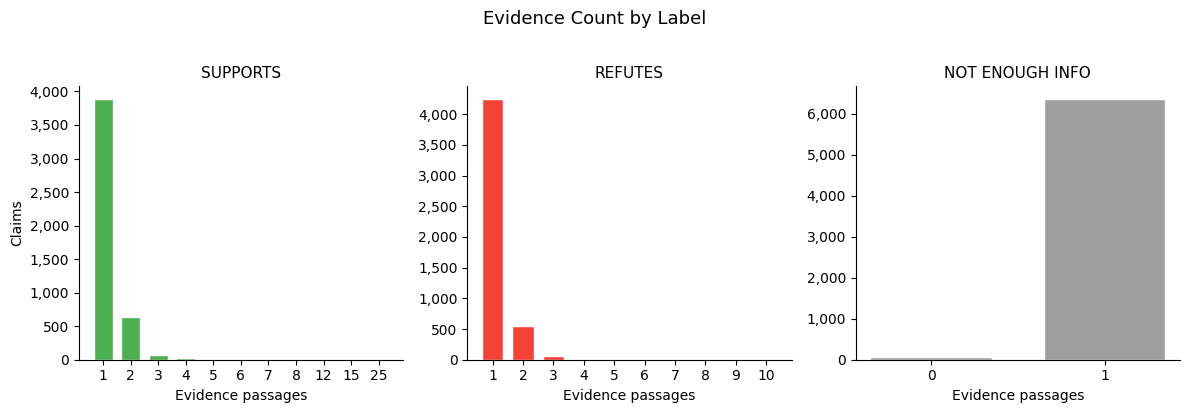

Saved → figures/01_evidence_count_by_label.png


In [12]:
# --- Evidence count stratified by label ---
# Shows that NEI claims mostly have 0 evidence — critical for Strategy A poisoning
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, (label, color) in zip(axes, zip(LABEL_ORDER, COLORS)):
    sub = df[df["label"] == label]["evidence_count"]
    vc = sub.value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor="white", width=0.7)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Evidence passages")
    ax.set_ylabel("Claims" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Evidence Count by Label", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/01_evidence_count_by_label.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_evidence_count_by_label.png")

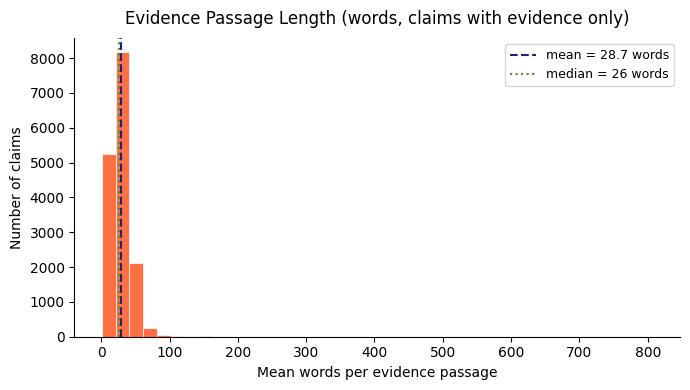

Saved → figures/01_evidence_passage_length.png

Evidence passage length stats (words):
count    15873.000000
mean        28.691626
std         16.811702
min          1.000000
25%         19.000000
50%         26.000000
75%         35.000000
max        807.000000


In [13]:
# --- Evidence passage length distribution ---
# Only claims with at least one evidence passage
ev_words = df[df["evidence_count"] > 0]["evidence_mean_words"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ev_words, bins=40, color="#FF7043", edgecolor="white", linewidth=0.5)
ax.axvline(ev_words.mean(), color="#1A237E", linestyle="--", linewidth=1.5,
           label=f"mean = {ev_words.mean():.1f} words")
ax.axvline(ev_words.median(), color="#558B2F", linestyle=":", linewidth=1.5,
           label=f"median = {ev_words.median():.0f} words")

ax.set_title("Evidence Passage Length (words, claims with evidence only)", fontsize=12, pad=10)
ax.set_xlabel("Mean words per evidence passage")
ax.set_ylabel("Number of claims")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_evidence_passage_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_evidence_passage_length.png")

print(f"\nEvidence passage length stats (words):")
print(ev_words.describe().to_string())

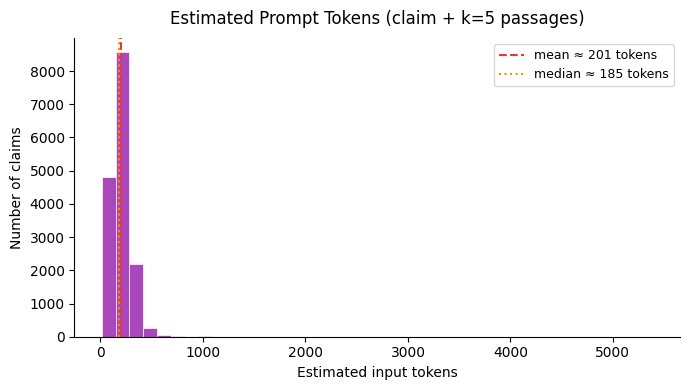

Saved → figures/01_prompt_token_estimate.png

Mean estimated input tokens/call : 201
Projected total input tokens     : ~0.66M (3,300 calls)


In [14]:
# --- Prompt token budget estimate ---
# Approximation: 1 token ≈ 0.75 words (standard heuristic)
# Prompt = claim + k retrieved passages (each ~evidence_mean_words words)
# We use per-claim actual evidence length where available, else global median
WORDS_PER_TOKEN = 0.75
ev_median_words = ev_words.median()

df["passage_words"] = df["evidence_mean_words"].apply(
    lambda w: w if w > 0 else ev_median_words
)
df["estimated_prompt_tokens"] = (
    (df["claim_len"] + K * df["passage_words"]) / WORDS_PER_TOKEN
).astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["estimated_prompt_tokens"], bins=40, color="#AB47BC",
        edgecolor="white", linewidth=0.5)
ax.axvline(df["estimated_prompt_tokens"].mean(), color="#E53935", linestyle="--",
           linewidth=1.5, label=f"mean ≈ {df['estimated_prompt_tokens'].mean():.0f} tokens")
ax.axvline(df["estimated_prompt_tokens"].median(), color="#FB8C00", linestyle=":",
           linewidth=1.5, label=f"median ≈ {df['estimated_prompt_tokens'].median():.0f} tokens")

ax.set_title(f"Estimated Prompt Tokens (claim + k={K} passages)", fontsize=12, pad=10)
ax.set_xlabel("Estimated input tokens")
ax.set_ylabel("Number of claims")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/01_prompt_token_estimate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/01_prompt_token_estimate.png")

mean_tok = df["estimated_prompt_tokens"].mean()
total_calls = 3300
print(f"\nMean estimated input tokens/call : {mean_tok:.0f}")
print(f"Projected total input tokens     : ~{mean_tok * total_calls / 1e6:.2f}M "
      f"({total_calls:,} calls)")

In [15]:
# --- Summary table ---
summary = pd.DataFrame({
    "label": LABEL_ORDER,
    "count": [counts[l] for l in LABEL_ORDER],
    "pct": [100 * counts[l] / len(df) for l in LABEL_ORDER],
    "mean_claim_len": [df[df["label"] == l]["claim_len"].mean() for l in LABEL_ORDER],
    "mean_evidence_count": [df[df["label"] == l]["evidence_count"].mean() for l in LABEL_ORDER],
    "mean_passage_words": [
        df[(df["label"] == l) & (df["evidence_count"] > 0)]["evidence_mean_words"].mean()
        for l in LABEL_ORDER
    ],
})
summary = summary.set_index("label")
summary["pct"] = summary["pct"].map("{:.1f}%".format)
summary["mean_claim_len"] = summary["mean_claim_len"].map("{:.1f}".format)
summary["mean_evidence_count"] = summary["mean_evidence_count"].map("{:.2f}".format)
summary["mean_passage_words"] = summary["mean_passage_words"].map("{:.1f}".format)
print(summary.to_string())

                 count    pct mean_claim_len mean_evidence_count mean_passage_words
label                                                                              
SUPPORTS          4638  29.1%            7.6                1.22               28.6
REFUTES           4887  30.7%            7.9                1.17               28.1
NOT ENOUGH INFO   6410  40.2%            8.3                0.99               29.2
